<a href="https://colab.research.google.com/github/KoreJosh/Health-Insurance-Charge-Prediction/blob/main/Health_Insurance_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Lasso
from xgboost import XGBRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_selection import RFE

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Data/insurance.csv')

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(1337, 7)

['female' 'male']
sex
male      675
female    662
Name: count, dtype: int64


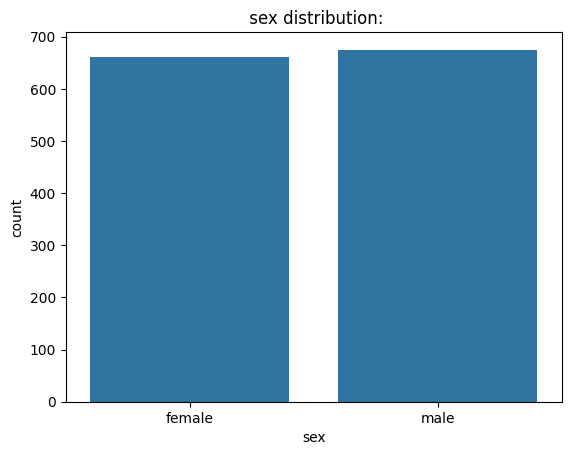

['yes' 'no']
smoker
no     1063
yes     274
Name: count, dtype: int64


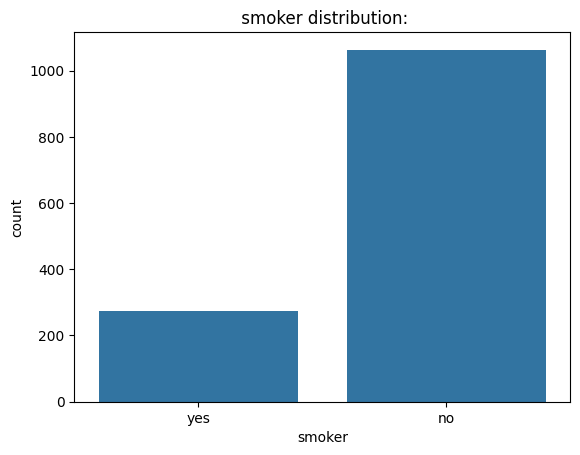

['southwest' 'southeast' 'northwest' 'northeast']
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


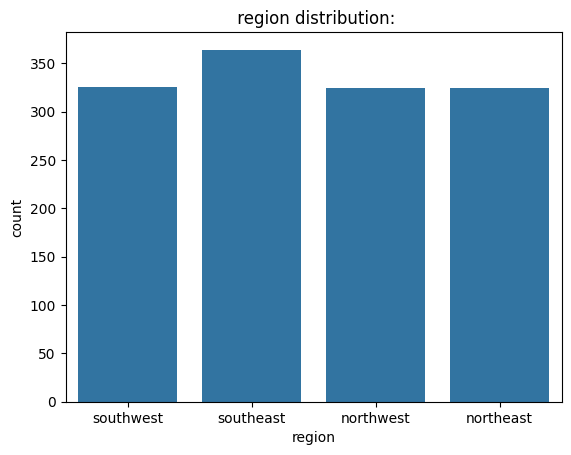

In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(df[col].unique())
        print(df[col].value_counts())
        sns.countplot(x=col, data = df)
        plt.title(f" {col} distribution:" )
        plt.show()


In [ ]:
cols = list(df.columns)
catCols, numCols = [], []
for col in cols:
    if df[col].dtype in ['int64', 'int32 ', 'float32', 'float64']:
        numCols.append(col)
    else:
        catCols.append(col)

numDf = df[numCols]
catDf = df[catCols]


In [ ]:
#inspet  numeical data for outliers

def intQtRang(col):
    q3, q1 = np.percentile(col, [75,25])
    iqr = q3 - q1
    upperLim = q3 + 1.5*iqr
    lowerLim = q1 - 1.5*iqr
    return upperLim, lowerLim

outlierCol = []
for col in numDf.columns:
    if col != 'id':
        print('-------------------------------------------------------------')

        UL, LL = intQtRang(numDf[col])

        print(f'upper limit is {UL}')
        print(f'lower limit is {LL}')

        total_outlier = len(numDf.loc[numDf[col]< LL, col]) + len(numDf.loc[numDf[col]>UL,col])
        percent_outlier = (total_outlier/len(numDf.index))*100
        print('percentage of outliers in: %s is (%.1f%%)' % (col, percent_outlier))
        print("---------------------------------------------------------------")

        if percent_outlier > 0:
            print(f'heavy prsence of outlier in {col}')
            outlierCol.append(col)
        print("---------------------------------------------------------------")


-------------------------------------------------------------
upper limit is 87.0
lower limit is -9.0
percentage of outliers in: age is (0.0%)
---------------------------------------------------------------
---------------------------------------------------------------
-------------------------------------------------------------
upper limit is 47.31500000000001
lower limit is 13.674999999999994
percentage of outliers in: bmi is (0.7%)
---------------------------------------------------------------
heavy prsence of outlier in bmi
---------------------------------------------------------------
-------------------------------------------------------------
upper limit is 5.0
lower limit is -3.0
percentage of outliers in: children is (0.0%)
---------------------------------------------------------------
---------------------------------------------------------------
-------------------------------------------------------------
upper limit is 34524.777625
lower limit is -13120.716174999998

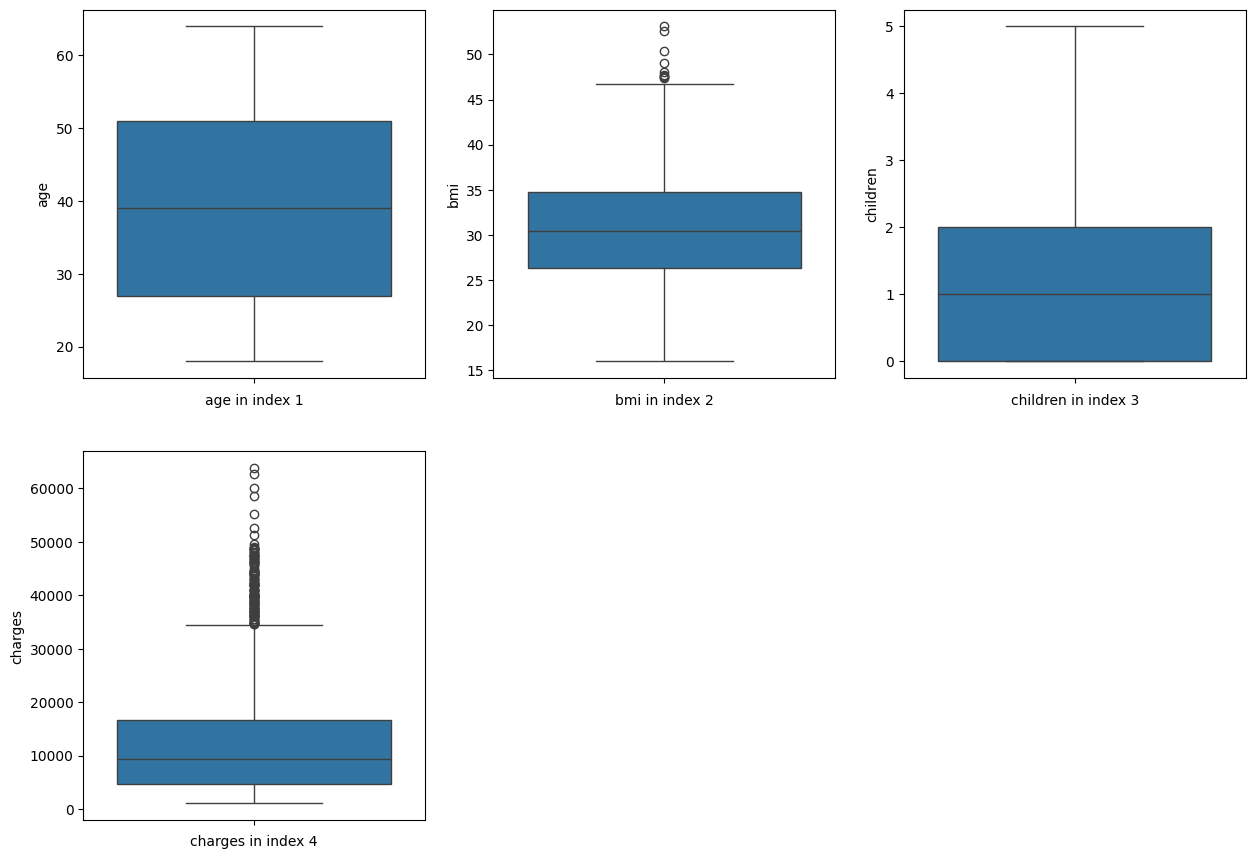

In [ ]:
#code  to visualize the outliers in numerical columns

i = 1

plt.figure(figsize=(15,22))
for col in numDf.columns:
    plt.subplot(4,3,i)
    sns.boxplot(y= col, data = df)
    plt.xlabel(f'{col} in index {i}')
    i+=1
plt.show()

In [ ]:
#currently not dropping the outliers due low datasets.

In [ ]:
#checking for skewness

numDf.skew()

,0
age,0.054781
bmi,0.283914
children,0.937421
charges,1.515391


In [ ]:
#treating the catgorical columns

##encoding the categorical columns

encoder = LabelEncoder()
for col in catDf:
    catDf[col] = encoder.fit_transform(catDf[col])

<ipython-input-82-8598c8281a0b>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  catDf[col] = encoder.fit_transform(catDf[col])
<ipython-input-82-8598c8281a0b>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  catDf[col] = encoder.fit_transform(catDf[col])
<ipython-input-82-8598c8281a0b>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-d

In [ ]:
catDf

,sex,smoker,region
0,0,1,3
1,1,0,2
2,1,0,2
3,1,0,1
4,1,0,1
...,...,...,...
1333,1,0,1
1334,0,0,0
1335,0,0,2
1336,0,0,3


In [ ]:
df1 = pd.concat([numDf, catDf], axis =1)

In [ ]:
df1

,age,bmi,children,charges,sex,smoker,region
0,19,27.900,0,16884.92400,0,1,3
1,18,33.770,1,1725.55230,1,0,2
2,28,33.000,3,4449.46200,1,0,2
3,33,22.705,0,21984.47061,1,0,1
4,32,28.880,0,3866.85520,1,0,1
...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,1,0,1
1334,18,31.920,0,2205.98080,0,0,0
1335,18,36.850,0,1629.83350,0,0,2
1336,21,25.800,0,2007.94500,0,0,3


In [ ]:
# Standardize

y = df1.charges

X = df1.drop('charges', axis=1).values


scaler = StandardScaler().fit(X)
standX = scaler.transform(X)

df2 = pd.DataFrame(standX, columns=list(df.columns)[:-1])

In [ ]:
df2['charges'] =y.reset_index(drop=True)

In [ ]:
df2

,age,sex,bmi,children,smoker,region,charges
0,-1.440418,-0.453160,-0.909234,-1.009771,1.969660,1.343163,16884.92400
1,-1.511647,0.509422,-0.079442,0.990324,-0.507702,0.438017,1725.55230
2,-0.799350,0.383155,1.580143,0.990324,-0.507702,0.438017,4449.46200
3,-0.443201,-1.305052,-0.909234,0.990324,-0.507702,-0.467128,21984.47061
4,-0.514431,-0.292456,-0.909234,0.990324,-0.507702,-0.467128,3866.85520
...,...,...,...,...,...,...,...
1332,0.767704,0.050269,1.580143,0.990324,-0.507702,-0.467128,10600.54830
1333,-1.511647,0.206053,-0.909234,-1.009771,-0.507702,-1.372274,2205.98080
1334,-1.511647,1.014490,-0.909234,-1.009771,-0.507702,0.438017,1629.83350
1335,-1.297958,-0.797524,-0.909234,-1.009771,-0.507702,1.343163,2007.94500


In [ ]:
df1 = df1[['age', 'bmi', 'children', 'sex', 'smoker', 'region', 'charges']]
df1

,age,bmi,children,sex,smoker,region,charges
0,19,27.900,0,0,1,3,16884.92400
1,18,33.770,1,1,0,2,1725.55230
2,28,33.000,3,1,0,2,4449.46200
3,33,22.705,0,1,0,1,21984.47061
4,32,28.880,0,1,0,1,3866.85520
...,...,...,...,...,...,...,...
1333,50,30.970,3,1,0,1,10600.54830
1334,18,31.920,0,0,0,0,2205.98080
1335,18,36.850,0,0,0,2,1629.83350
1336,21,25.800,0,0,0,3,2007.94500


In [ ]:
#feature selection

def featureSelector(df, k):

    # Define the number of features in the dataset
    #n = len(df.columns)  # Total number of columns (features + target)
    #k = n // 2           # Number of features to select (half of the total columns)
    #m = n - 1            # Index of the last feature column (before the target column)

    # Separate the independent features (X) and the target variable (y)
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    model = input('write wheather the model follows a LinearRegression or LogicalRegression :', )

    if model == 'LinearRegression':
        # Initialize the model (Linear Regression in this case)
        model = LinearRegression()

        # Apply Recursive Feature Elimination (RFE)
        rfeSelector = RFE(estimator=model, n_features_to_select=k)
        rfeSelector.fit(X, y)

        # Initialize an empty list to store the names of selected features
        feats = []

        # Loop through features and selection status
        for feat, is_selected in zip(df.columns[:-1], rfeSelector.support_):
            if is_selected:  # If the feature is selected, add it to the list
                feats.append(feat)

        # Create a DataFrame with the selected features
        df_selected = df[feats]

        # Add the target variable back to the selected features DataFrame
        ydf = pd.DataFrame(y, columns=[df.columns[-1]])
        df_selected = pd.concat([df_selected, ydf], axis=1)

        y = df_selected.iloc[: ,-1]
        X = df_selected.iloc[:, :-1]


        feature_names = list(df_selected.columns)[:-1]

        model = ExtraTreesRegressor()

        model.fit(X,y)

        #plot graph of feature importances for better visualization
        feat_importances=pd.Series(model.feature_importances_, index=X.columns)
        feat_importances.nlargest(k).plot(kind='barh')
        plt.show()


    else:                          # Initialize the model (Logistic Regression in this case)
        model = LogisticRegression()

        # Apply Recursive Feature Elimination (RFE)
        rfeSelector = RFE(estimator=model, n_features_to_select=k)
        rfeSelector.fit(X, y)

        # Initialize an empty list to store the names of selected features
        feats = []

        # Loop through features and selection status
        for feat, is_selected in zip(df.columns[:-1], rfeSelector.support_):
            if is_selected:  # If the feature is selected, add it to the list
                feats.append(feat)

        # Create a DataFrame with the selected features
        df_selected = df[feats]

        # Add the target variable back to the selected features DataFrame
        ydf = pd.DataFrame(y, columns=[df.columns[-1]])
        df_selected = pd.concat([df_selected, ydf], axis=1)

        y = df_selected.iloc[: ,-1]
        X = df_selected.iloc[:, :-1]


        feature_names = list(df_selected.columns)[:-1]

        model = ExtraTreesClassifier()

        model.fit(X,y)

        #plot graph of feature importances for better visualization
        feat_importances=pd.Series(model.feature_importances_, index=X.columns)
        feat_importances.nlargest(k).plot(kind='barh')
        plt.show()

    return df_selected


write wheather the model follows a LinearRegression or LogicalRegression :LinearRegression


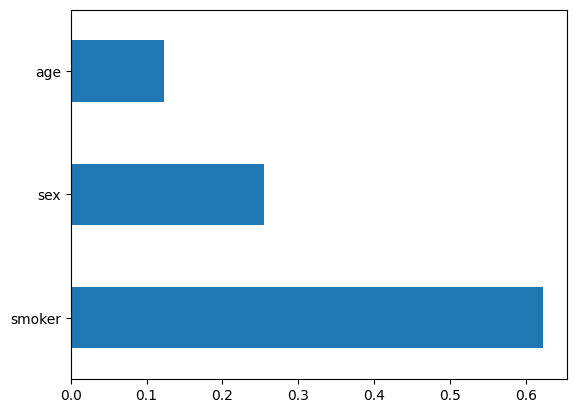

,age,sex,smoker,charges
0,-1.440418,-0.453160,1.969660,16884.92400
1,-1.511647,0.509422,-0.507702,1725.55230
2,-0.799350,0.383155,-0.507702,4449.46200
3,-0.443201,-1.305052,-0.507702,21984.47061
4,-0.514431,-0.292456,-0.507702,3866.85520
...,...,...,...,...
1332,0.767704,0.050269,-0.507702,10600.54830
1333,-1.511647,0.206053,-0.507702,2205.98080
1334,-1.511647,1.014490,-0.507702,1629.83350
1335,-1.297958,-0.797524,-0.507702,2007.94500


In [ ]:
featureSelector(df2,3) # the three important features that contribute to the health insurance charge of our patients are:

In [ ]:
df1.head()

,age,bmi,children,sex,smoker,region,charges
0,19,27.900,0,0,1,3,16884.92400
1,18,33.770,1,1,0,2,1725.55230
2,28,33.000,3,1,0,2,4449.46200
3,33,22.705,0,1,0,1,21984.47061
4,32,28.880,0,1,0,1,3866.85520


In [ ]:
#Modelling

##Splitting the dataset

X= df1.drop('charges',axis =1)
y = df1['charges']

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size =.3)

In [ ]:
models = {'LinearRegression': LinearRegression(),
         'RandomForestRegressor': RandomForestRegressor(),
         'Lasso':Lasso(alpha=.1)}

results = []

for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    #acc_score = model.score(X_test,y_test)

    #calculate the metrics

    mae = mean_absolute_error(y_test,y_pred)
    mse = mean_squared_error(y_test,y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
    'Model': name,
    #'Accuracy': acc_score,
    'MAE': round(mae,2),
    'RMSE': round(rmse,2),
    'R2': round(r2,2)})

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

                   Model      MAE     RMSE    R2
0       LinearRegression  4182.80  6239.81  0.77
1  RandomForestRegressor  2633.51  4834.14  0.86
2                  Lasso  4182.85  6239.87  0.77


In [ ]:
# Define models with basic configurations
models = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(random_state=42),
    'Lasso': Lasso(alpha=0.1),
    'XGBoost': XGBRegressor(random_state=42)  # Added XGBoost
}

# Hyperparameter grid for RandomForest
rf_params = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Hyperparameter grid for XGBoost
xgb_params = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2]
}

results = []

for name, model in models.items():
    if name == 'RandomForestRegressor':
        # Tune RandomForest
        rf_search = RandomizedSearchCV(
            model,
            param_distributions=rf_params,
            n_iter=20,
            cv=5,
            scoring='r2',
            n_jobs=-1,
            random_state=42
        )
        rf_search.fit(X_train, y_train)
        best_model = rf_search.best_estimator_
        best_params = rf_search.best_params_

    elif name == 'XGBoost':
        # Tune XGBoost
        xgb_search = RandomizedSearchCV(
            model,
            param_distributions=xgb_params,
            n_iter=20,
            cv=5,
            scoring='r2',
            n_jobs=-1,
            random_state=42
        )
        xgb_search.fit(X_train, y_train)
        best_model = xgb_search.best_estimator_
        best_params = xgb_search.best_params_

    else:
        # No tuning for LinearRegression and Lasso
        model.fit(X_train, y_train)
        best_model = model
        best_params = None

    # Predict and evaluate
    y_pred = best_model.predict(X_test)

    results.append({
        'Model': name,
        'Best Params': best_params,
        'MAE': round(mean_absolute_error(y_test, y_pred), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
        'R2': round(r2_score(y_test, y_pred), 4)  # More precision for R²
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print(results_df.sort_values('R2', ascending=False))

                   Model                                        Best Params  \
3                XGBoost  {'subsample': 1.0, 'n_estimators': 100, 'max_d...   
1  RandomForestRegressor  {'n_estimators': 200, 'min_samples_split': 5, ...   
0       LinearRegression                                               None   
2                  Lasso                                               None   

       MAE     RMSE      R2  
3  2550.27  4592.73  0.8767  
1  3018.32  4987.22  0.8546  
0  4182.80  6239.81  0.7725  
2  4182.85  6239.87  0.7725  


In [ ]:
results_df = pd.DataFrame(results)
# Define a highlighting function to mark the highest precision, recall, and accuracy
def highlight_max(val):
    style = ''  # Initialize style as an empty string
    if isinstance(val, (int, float)):

        if val == results_df['MAE'].min():
            style += 'background-color: rgba(0, 128, 0, 0.3); color: black; font-weight: bold;'
        if val == results_df['RMSE'].min():
            style += 'background-color: rgba(0, 128, 0, 0.3); color: black; font-weight: bold;'
        if val == results_df['R2'].max():
            style += 'background-color: rgba(0, 128, 0, 0.3); color: black; font-weight: bold;'
    return style

# Apply the highlighting function to the entire DataFrame
styled_results = results_df.style.applymap(highlight_max)

print(results_df)

                   Model                                        Best Params  \
0       LinearRegression                                               None   
1  RandomForestRegressor  {'n_estimators': 200, 'min_samples_split': 5, ...   
2                  Lasso                                               None   
3                XGBoost  {'subsample': 1.0, 'n_estimators': 100, 'max_d...   

       MAE     RMSE      R2  
0  4182.80  6239.81  0.7725  
1  3018.32  4987.22  0.8546  
2  4182.85  6239.87  0.7725  
3  2550.27  4592.73  0.8767  


<ipython-input-96-bb3b585183c4>:18: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_results = results_df.style.applymap(highlight_max)


In [ ]:
styled_results

,Model,Best Params,MAE,RMSE,R2
0,LinearRegression,None,4182.800000,6239.810000,0.772500
1,RandomForestRegressor,"{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}",3018.320000,4987.220000,0.854600
2,Lasso,None,4182.850000,6239.870000,0.772500
3,XGBoost,"{'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}",2550.270000,4592.730000,0.876700


## Using Pytorch on the Insurance Data
using MLP(multi_layered perceptron) a knowlegde of deeplearning on the dataset to see if it would outperform our ML models in predicting the insurance charge of our patients


In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
df1.head()

,age,bmi,children,sex,smoker,region,charges
0,19,27.900,0,0,1,3,16884.92400
1,18,33.770,1,1,0,2,1725.55230
2,28,33.000,3,1,0,2,4449.46200
3,33,22.705,0,1,0,1,21984.47061
4,32,28.880,0,1,0,1,3866.85520


In [ ]:
# Data Preparation
X = df1.iloc[:,:-1].values
y = df1.iloc[:,-1].values.reshape(-1,1)

# Scale features and target
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Train/Test/Val Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

# Dataset Class
class InsuranceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets and dataloaders
train_data = InsuranceDataset(X_train, y_train)
val_data = InsuranceDataset(X_val, y_val)
test_data = InsuranceDataset(X_test, y_test)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

# Improved Model
class InsuranceModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)  # No activation for regression
        )

    def forward(self, x):
        return self.net(x)

model = InsuranceModel(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.001)

# Training Loop
for epoch in range(50):  # More epochs
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            outputs = model(X_val)
            val_loss += criterion(outputs, y_val).item()

    print(f'Epoch {epoch+1}')
    print(f'Train Loss: {train_loss/len(train_loader):.4f}')
    print(f'Val Loss: {val_loss/len(val_loader):.4f}')
    print('-'*40)

# Evaluation (with proper regression metrics)
def evaluate(model, loader, scaler_y):
    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        for X, y in loader:
            preds = model(X)
            predictions.extend(preds.numpy())
            actuals.extend(y.numpy())

    # Inverse transform to original scale
    predictions = scaler_y.inverse_transform(np.array(predictions).reshape(-1,1))
    actuals = scaler_y.inverse_transform(np.array(actuals).reshape(-1,1))

    # Calculate metrics
    mae = np.mean(np.abs(predictions - actuals))
    rmse = np.sqrt(np.mean((predictions - actuals)**2))
    #r2 = 1 - (np.sum((actuals - predictions)**2) / np.sum((actuals - np.mean(actuals))**2))
    r2 = 1 - (np.sum((actuals - predictions)**2) / np.sum((actuals - np.mean(actuals))**2))

    print(f'MAE: ${mae:.2f}')
    print(f'RMSE: ${rmse:.2f}')
    print(f'R²: {r2:.4f}')

print("\nTest Set Evaluation:")
evaluate(model, test_loader, scaler_y)

Epoch 1
Train Loss: 0.7393
Val Loss: 0.5970
----------------------------------------
Epoch 2
Train Loss: 0.3350
Val Loss: 0.2340
----------------------------------------
Epoch 3
Train Loss: 0.2043
Val Loss: 0.1835
----------------------------------------
Epoch 4
Train Loss: 0.1873
Val Loss: 0.1721
----------------------------------------
Epoch 5
Train Loss: 0.1695
Val Loss: 0.1611
----------------------------------------
Epoch 6
Train Loss: 0.1589
Val Loss: 0.1622
----------------------------------------
Epoch 7
Train Loss: 0.1477
Val Loss: 0.1627
----------------------------------------
Epoch 8
Train Loss: 0.1432
Val Loss: 0.1609
----------------------------------------
Epoch 9
Train Loss: 0.1438
Val Loss: 0.1580
----------------------------------------
Epoch 10
Train Loss: 0.1430
Val Loss: 0.1614
----------------------------------------
Epoch 11
Train Loss: 0.1462
Val Loss: 0.1692
----------------------------------------
Epoch 12
Train Loss: 0.1396
Val Loss: 0.1570
------------------

In [ ]:
# After training:
print("\nTest Set Evaluation:")
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X, y in test_loader:
        preds = model(X)
        predictions.extend(preds.numpy())
        actuals.extend(y.numpy())

# Convert to original scale
predictions = scaler_y.inverse_transform(np.array(predictions).reshape(-1,1))
actuals = scaler_y.inverse_transform(np.array(actuals).reshape(-1,1))

# Calculate metrics
mae = np.mean(np.abs(predictions - actuals))
rmse = np.sqrt(np.mean((predictions - actuals)**2))
r2 = r2_score(actuals, predictions)  # Using sklearn's r2_score for stability

print(f'MAE: ${mae:.2f}')
print(f'RMSE: ${rmse:.2f}')
print(f'R²: {r2:.4f}')


Test Set Evaluation:
MAE: $3169.01
RMSE: $4834.46
R²: 0.8634
